<a href="https://colab.research.google.com/github/iamviplavkr/viplav_kumar_23FE10CSE00421_ML/blob/main/LAB_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load dataset
df = pd.read_csv("/content/student-por.csv", sep=';')

print(df.head())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5        0  11  13  13  

[5 rows x 33 columns]


In [7]:
# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Convert to X and y (like reference)
X = df.drop('G3', axis=1).values
y = df['G3'].values

# Convert regression → classification (IMPORTANT)
# Pass if marks >=10
y = (y >= 10).astype(int)

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (649, 32)
Target Shape: (649,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (519, 32)
Testing Shape: (130, 32)


In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
model = Sequential()

model.add(Dense(16, activation='relu', input_dim=X.shape[1]))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.2964 - loss: 0.9276 - val_accuracy: 0.2692 - val_loss: 0.8816
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4024 - loss: 0.8103 - val_accuracy: 0.3654 - val_loss: 0.7755
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5301 - loss: 0.7221 - val_accuracy: 0.5481 - val_loss: 0.6947
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6361 - loss: 0.6565 - val_accuracy: 0.7019 - val_loss: 0.6296
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7229 - loss: 0.6020 - val_accuracy: 0.7692 - val_loss: 0.5772
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7759 - loss: 0.5567 - val_accuracy: 0.8173 - val_loss: 0.5301
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8265 - loss: 0.5143 - val_accuracy: 0.8750 - val_loss: 0.4905
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8699 - loss: 0.4764 - val_accuracy: 0.8846 - val_los

In [13]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9231 - loss: 0.1930 
Test Accuracy: 0.9230769276618958
Test Loss: 0.19303014874458313


In [14]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

print(y_pred[:10])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
[[ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [False]
 [ True]
 [ True]]


In [15]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Confusion Matrix:
[[ 11   4]
 [  6 109]]
Accuracy: 0.9230769230769231
              precision    recall  f1-score   support

           0       0.65      0.73      0.69        15
           1       0.96      0.95      0.96       115

    accuracy                           0.92       130
   macro avg       0.81      0.84      0.82       130
weighted avg       0.93      0.92      0.93       130



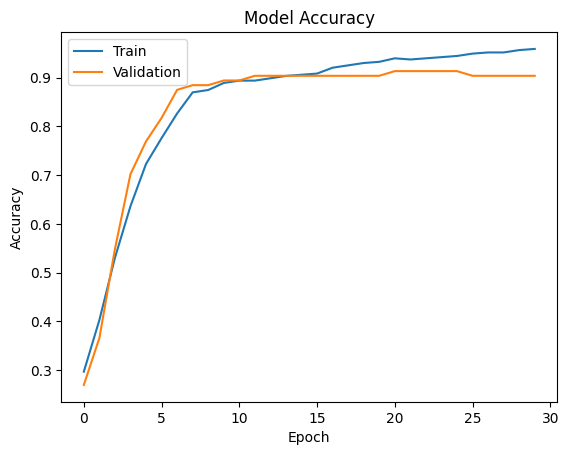

In [19]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])
plt.show()

In [20]:
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1, 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1, 1)

In [21]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout

model = Sequential()

model.add(Conv2D(32, (2,1), activation='relu', input_shape=(X.shape[1],1,1)))
model.add(MaxPooling2D(pool_size=(2,1)))

model.add(Conv2D(64, (2,1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,1)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [23]:
history = model.fit(
    X_train_cnn,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.8193 - loss: 0.5312 - val_accuracy: 0.8750 - val_loss: 0.3876
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8265 - loss: 0.4521 - val_accuracy: 0.8750 - val_loss: 0.3723
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8289 - loss: 0.4195 - val_accuracy: 0.8750 - val_loss: 0.3450
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8313 - loss: 0.3970 - val_accuracy: 0.8654 - val_loss: 0.3279
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8386 - loss: 0.3619 - val_accuracy: 0.8750 - val_loss: 0.3255
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8458 - loss: 0.3534 - val_accuracy: 0.8654 - val_loss: 0.3126
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8458 - loss: 0.3326 - val_accuracy: 0.8654 - val_loss: 0.2998
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8602 - loss: 0.3232 - val_accuracy: 0.8558 - v

In [24]:
test_loss, test_accuracy = model.evaluate(X_test_cnn, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8692 - loss: 0.3138 
Test Accuracy: 0.8692307472229004
Test Loss: 0.31378841400146484
